<a href="https://colab.research.google.com/github/Jackline-Jebet/correlation-regimes/blob/main/correlation_breakdown_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Correlation breakdown across regimes

Rolling correlation analysis for the article on why diversification fails when it is needed.

Five asset classes, 2005 to 2022, same universe as the multi-asset research project so the numbers stay consistent with work already published.

**What this produces**

- A period statistics table: mean pairwise correlation and equity–bond correlation, pre-crisis / crisis / recovery / 2022
- `fig1_rolling_correlation.png` — equity–bond correlation on a rolling window
- `fig2_regime_correlations.png` — average pairwise correlation across all five assets

Run all cells, then download the two PNGs from the last cell.

*Jackline Jebet · MSc Financial Engineering, WorldQuant University*

## Setup

In [1]:
!pip install yfinance --quiet --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 9.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Site palette, so the figures drop straight into the article
PAPER, INK, ACCENT, MUTED = "#f5f0e8", "#0d0d0d", "#b8860b", "#6b6355"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER,
    "savefig.facecolor": PAPER, "text.color": INK,
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#d8d0c0", "axes.grid": True,
    "grid.color": "#e8e2d8", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 12,
})

TICKERS = {
    "Equities":    "SPY",
    "Long bonds":  "TLT",
    "Short bonds": "SHY",
    "Gold":        "GLD",
    "Oil":         "USO",
}
START, END = "2005-01-01", "2022-12-31"
WINDOW = 126   # about six months of trading days

print("ready")

ready


## Load the data

GLD launched in November 2004 and USO in April 2006, so dropping incomplete rows starts the sample in 2006. That is fine — it still covers the crisis with two years of lead-in.

In [3]:
px = yf.download(list(TICKERS.values()), start=START, end=END,
                 auto_adjust=True, progress=False)["Close"]
px = px.rename(columns={v: k for k, v in TICKERS.items()})
px = px[list(TICKERS.keys())].dropna()

rets = np.log(px / px.shift(1)).dropna()

print(f"{len(rets)} daily observations, "
      f"{rets.index[0].date()} to {rets.index[-1].date()}")
rets.describe().T[["count", "mean", "std", "min", "max"]]

4211 daily observations, 2006-04-11 to 2022-12-30


,count,mean,std,min,max
Ticker,,,,,
Equities,4211.0,0.000334,0.012702,-0.115887,0.135578
Long bonds,4211.0,0.000156,0.009415,-0.069011,0.072502
Short bonds,4211.0,0.000063,0.000876,-0.006587,0.007071
Gold,4211.0,0.000248,0.011403,-0.091905,0.106974
Oil,4211.0,-0.000487,0.023865,-0.291891,0.154151


## Period statistics

The table the article quotes. **Read it before writing anything** — if the crisis window is not clearly higher than pre-crisis, the argument needs adjusting rather than the numbers.

In [4]:
def mean_pairwise(frame):
    """Average off-diagonal correlation."""
    c = frame.corr().values
    n = c.shape[0]
    return (c.sum() - n) / (n * n - n)

PERIODS = [
    ("Pre-crisis (2006–2007)",      "2006-01-01", "2007-06-30"),
    ("Crisis (Sep 2008–Mar 2009)",   "2008-09-01", "2009-03-31"),
    ("Recovery (2010–2019)",         "2010-01-01", "2019-12-31"),
    ("2022",                         "2022-01-01", "2022-12-31"),
]

rows = []
for label, a, b in PERIODS:
    w = rets.loc[a:b]
    rows.append({
        "Period": label,
        "Days": len(w),
        "Mean pairwise": round(mean_pairwise(w), 3),
        "Equity–bond": round(w["Equities"].corr(w["Long bonds"]), 3),
    })

table = pd.DataFrame(rows)
display(table)
print("\nPaste these into the article's placeholder table.")

,Period,Days,Mean pairwise,Equity–bond
0,Pre-crisis (2006–2007),307,0.155,0.018
1,Crisis (Sep 2008–Mar 2009),146,-0.031,-0.444
2,Recovery (2010–2019),2516,0.040,-0.483
3,2022,251,0.251,0.084



Paste these into the article's placeholder table.


## Figure 1 — equity–bond rolling correlation

The relationship a balanced portfolio depends on, measured over time rather than assumed.

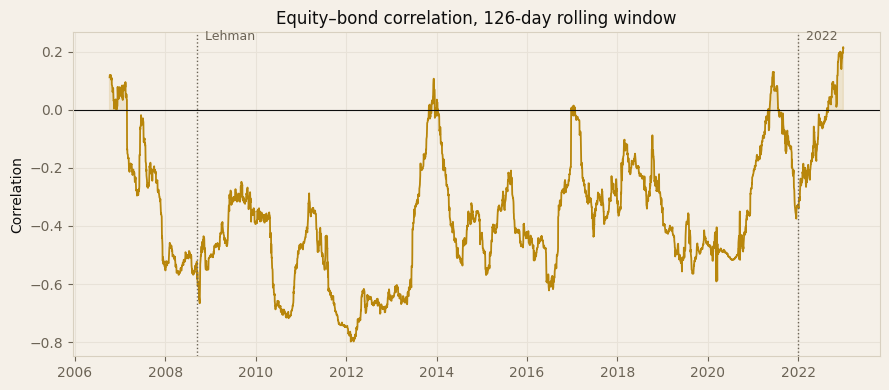

range: -0.798 to +0.216
share of days positive: 6.9%


In [5]:
eb = rets["Equities"].rolling(WINDOW).corr(rets["Long bonds"]).dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(eb.index, eb.values, color=ACCENT, linewidth=1.3)
ax.axhline(0, color=INK, linewidth=0.8)
ax.fill_between(eb.index, 0, eb.values, where=eb.values > 0,
                color=ACCENT, alpha=0.12)

for when, text in [("2008-09-15", "Lehman"), ("2022-01-01", "2022")]:
    ts = pd.Timestamp(when)
    if eb.index[0] <= ts <= eb.index[-1]:
        ax.axvline(ts, color=MUTED, linestyle=":", linewidth=1)
        ax.text(ts, ax.get_ylim()[1] * 0.9, "  " + text, fontsize=9, color=MUTED)

ax.set_title(f"Equity–bond correlation, {WINDOW}-day rolling window")
ax.set_ylabel("Correlation")
fig.tight_layout()
fig.savefig("fig1_rolling_correlation.png", dpi=160)
plt.show()

print(f"range: {eb.min():+.3f} to {eb.max():+.3f}")
print(f"share of days positive: {(eb > 0).mean():.1%}")

## Figure 2 — average pairwise correlation

Across all five asset classes. If diversification thins under stress, this rises when it is least wanted.

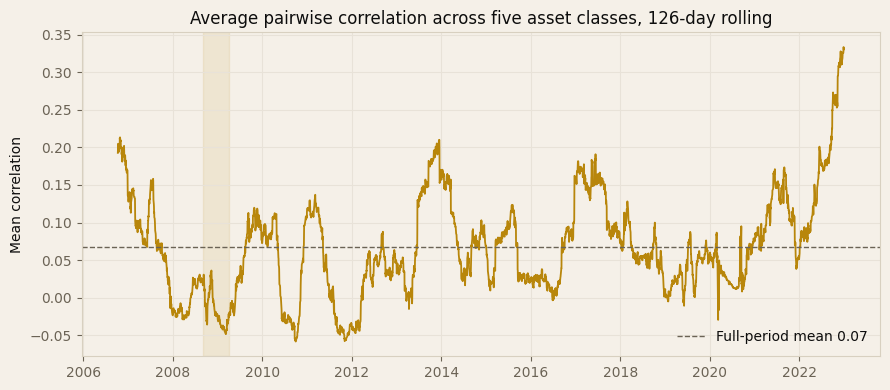

peak  0.333 on 2022-12-29
trough -0.058 on 2010-09-30


In [6]:
vals = {}
for i in range(WINDOW, len(rets) + 1):
    w = rets.iloc[i - WINDOW:i]
    vals[rets.index[i - 1]] = mean_pairwise(w)
mp = pd.Series(vals)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mp.index, mp.values, color=ACCENT, linewidth=1.3)
ax.axhline(mp.mean(), color=MUTED, linestyle="--", linewidth=1,
           label=f"Full-period mean {mp.mean():.2f}")
ax.axvspan(pd.Timestamp("2008-09-01"), pd.Timestamp("2009-03-31"),
           color=ACCENT, alpha=0.10)
ax.set_title(f"Average pairwise correlation across five asset classes, "
             f"{WINDOW}-day rolling")
ax.set_ylabel("Mean correlation")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("fig2_regime_correlations.png", dpi=160)
plt.show()

print(f"peak  {mp.max():.3f} on {mp.idxmax().date()}")
print(f"trough {mp.min():.3f} on {mp.idxmin().date()}")

In [8]:
risk = rets[["Equities", "Gold", "Oil"]]
for label, a, b in PERIODS:
    w = risk.loc[a:b]
    print(f"{label:<28} risk-asset mean pairwise: {mean_pairwise(w):+.3f}")
    print(f"{'':28} equity-gold {w['Equities'].corr(w['Gold']):+.3f}  "
          f"equity-oil {w['Equities'].corr(w['Oil']):+.3f}")

Pre-crisis (2006–2007)       risk-asset mean pairwise: +0.259
                             equity-gold +0.246  equity-oil +0.082
Crisis (Sep 2008–Mar 2009)   risk-asset mean pairwise: +0.271
                             equity-gold +0.039  equity-oil +0.559
Recovery (2010–2019)         risk-asset mean pairwise: +0.186
                             equity-gold -0.016  equity-oil +0.422
2022                         risk-asset mean pairwise: +0.241
                             equity-gold +0.193  equity-oil +0.108


## Download the figures

Copy both into `assets/` in the portfolio repo. The article already points at these filenames.

In [7]:
from google.colab import files

files.download("fig1_rolling_correlation.png")
files.download("fig2_regime_correlations.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>